# Econ 390 - Problem Set 11 Answers
## by M McMain
This problem set will cover OLS and Categorical Variables. Be sure to import any packages your code needs to run and make sure the code runs without any errors.

1. [1 Point] Read in `FUSION_annual_1995.dta` from my website. This is an expanded version of the `_EMP` version we've worked with in class.
   - Create the variable `EXPORTADOS` to be 1 if `EXPVAL>0` and 0 otherwise. *Hint: How do boolean variables act when cast as an int?*
   - Convert `EXPORTADOS` into a categorical variable with labels `"Not Exporting"` and `"Exporting"`

In [1]:
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf 
from statsmodels.iolib.summary2 import summary_col
econ390path = "https://m-mcmain.github.io/files/Econ390SP26/"

In [2]:
fusion_1995 = pd.read_stata(econ390path + "FUSION_annual_1995.dta")
fusion_1995["EXPORTADOS"] = (fusion_1995["EXPVAL"]>0).astype("int")
fusion_1995["EXPORTADOS"] = pd.Categorical.from_codes(fusion_1995["EXPORTADOS"],["Not Exporting", "Exporting"])
fusion_1995.head()

,NUI,Dvn,REGION,CIIU2,CIIU3,TAMANO,ANIO,FORPRO,PORNAC,POREXT,...,TOHSC,TOMSC,TOSC,EVTAS,EVBP,EVA,EMPTOT,VSTK,avg_sal,EXPORTADOS
0,10082,K,2,3819,3610,2,1995,1,100,0,...,0,0,0,5,5,4,15.0,85699.0,1882.666626,Not Exporting
1,10101,K,2,3721,2720,6,1995,1,0,0,...,0,0,0,10,10,10,452.0,216760048.0,7206.813965,Exporting
2,10103,6,2,3116,1531,4,1995,1,0,0,...,0,0,0,8,8,6,52.0,1567523.0,4863.653809,Not Exporting
3,10178,8,4,3114,1512,4,1995,1,100,0,...,0,0,0,6,6,4,74.0,140901.0,939.121643,Not Exporting
4,10220,2,5,3843,3312,6,1995,2,0,100,...,0,0,0,10,10,7,496.0,10962775.0,3814.221680,Exporting


2. [1 Point] Show an sns `lmplot` showing how total sales (`FABVAL`) are related to having more employees (`EMPTOT`)
   - In a cell below that plot, do the same thing but let both the slope and intercept be different for exporters compared to non-exporters *Hint: Check out the `hue` option*

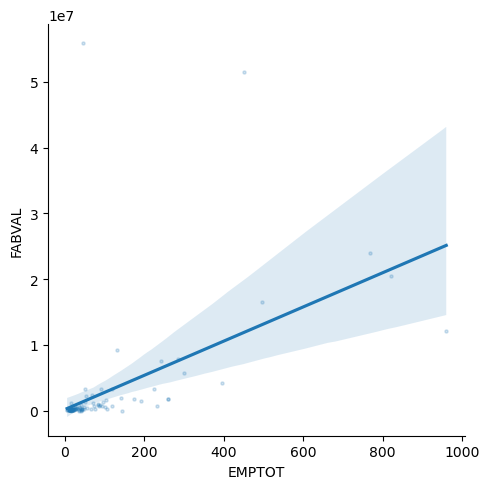

In [3]:
sns.lmplot(x="EMPTOT", y="FABVAL", data=fusion_1995, scatter_kws={'alpha':0.2, 's': 5});

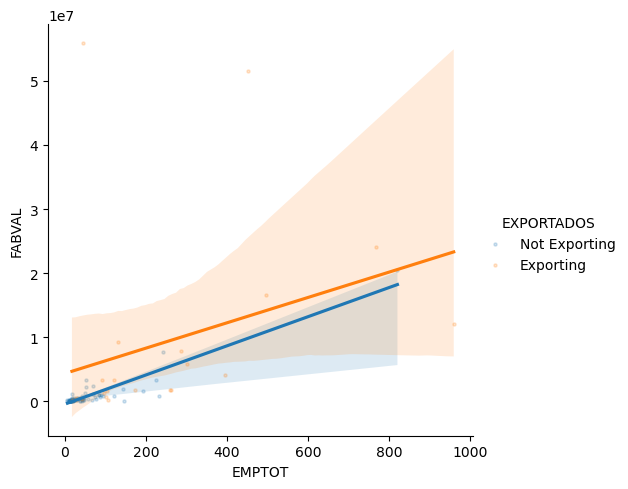

In [4]:
sns.lmplot(x="EMPTOT", y="FABVAL", hue="EXPORTADOS", data=fusion_1995, scatter_kws={'alpha':0.2, 's': 5});

3. [2 Points] Run a regression of total employees on total sales using `statsmodels.formula.api` and use the print function on the summary of the results. Make sure to use heteroskedastic standard errors.
   - In the cell below that, do the same but allow for the intercept only to differ for exporters compared to non-exporters
   - In the cell below that, do the same but allow both the slope and the intercept differ for exporters in the most efficient (least characters) way
   - In the cell below that, use `summary_col` to print all three model results next to each other. Make sure significance stars are shown
   - Reflect on the results. Reminder that these are simply correlations, there are almost certainly factors that affect both employment, export status, and total sales that are not controlled for here

In [5]:
model1 = smf.ols("FABVAL ~ EMPTOT", data = fusion_1995).fit(cov_type="HC1")
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                 FABVAL   R-squared:                       0.263
Model:                            OLS   Adj. R-squared:                  0.255
Method:                 Least Squares   F-statistic:                     13.40
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           0.000408
Time:                        14:14:10   Log-Likelihood:                -1719.3
No. Observations:                 100   AIC:                             3443.
Df Residuals:                      98   BIC:                             3448.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.765e+05   7.35e+05      0.240      0.8

In [6]:
model2 = smf.ols("FABVAL ~ EMPTOT + EXPORTADOS", data = fusion_1995).fit(cov_type="HC1")
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                 FABVAL   R-squared:                       0.304
Model:                            OLS   Adj. R-squared:                  0.289
Method:                 Least Squares   F-statistic:                     7.716
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           0.000776
Time:                        14:14:13   Log-Likelihood:                -1716.5
No. Observations:                 100   AIC:                             3439.
Df Residuals:                      97   BIC:                             3447.
Df Model:                           2                                         
Covariance Type:                  HC1                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept               -3

In [7]:
model3 = smf.ols("FABVAL ~ EMPTOT*EXPORTADOS", data = fusion_1995).fit(cov_type="HC1")
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                 FABVAL   R-squared:                       0.304
Model:                            OLS   Adj. R-squared:                  0.282
Method:                 Least Squares   F-statistic:                     28.78
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           2.33e-13
Time:                        14:14:15   Log-Likelihood:                -1716.5
No. Observations:                 100   AIC:                             3441.
Df Residuals:                      96   BIC:                             3451.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [8]:
print(summary_col([model1, model2, model3], stars=True))


                                  FABVAL I     FABVAL II       FABVAL III  
---------------------------------------------------------------------------
Intercept                      176490.8249   -345664.9401   -450253.2851***
                               (735491.1583) (436005.5471)  (119712.9030)  
EMPTOT                         26007.3903*** 20875.4223***  22729.3133***  
                               (7104.8774)   (7714.5197)    (2627.2788)    
EXPORTADOS[T.Exporting]                      4421652.7120   4782261.7507   
                                             (3386964.5873) (4245163.1234) 
EMPTOT:EXPORTADOS[T.Exporting]                              -2965.3436     
                                                            (12274.2777)   
R-squared                      0.2630        0.3035         0.3041         
R-squared Adj.                 0.2555        0.2891         0.2824         
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01
